# 4.4 Modèles de séquences : RNN, LSTM et attention

Les réseaux denses traitent chaque caractéristique d'entrée comme indépendante. Pas les séries temporelles : l'ordre des échantillons porte le signal. Ce carnet construit quatre modèles qui lisent une séquence, par sophistication croissante : un réseau récurrent simple, un LSTM, une couche d'auto-attention à une tête écrite à partir de zéro, et un petit encodeur *transformer*. Les quatre résolvent la même tâche de prévision sur les mêmes données, ce qui permet de les comparer directement.

Un neurone récurrent reçoit une entrée *et* la sortie qu'il a produite au pas de temps précédent. Parce que chaque pas réutilise la sortie du pas précédent, le réseau a une *mémoire*. Les cellules récurrentes simples ont la mémoire courte, de l'ordre de quelques dizaines de pas ; une bonne partie de ce carnet consiste à faire mieux.

![RNN](../img/rnn.svg)

Tiré de Dive into Deep Learning : un RNN à état caché. À chaque pas de temps, la cellule combine l'entrée courante avec l'état caché du pas précédent.

🖥️ [**Diapositives du cours — Séance 23 (lun. 23 nov.)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec23_networks_with_memory.html)

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import mlgeo_synth

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print(f"Detected device: {device}")

# The models in this notebook are tiny, and recurrent layers launch one small
# operation per time step, so accelerator overhead dominates any speedup.
# CPU is usually fastest for models this size.
device = torch.device("cpu")
print(f"Using device: {device}")

Detected device: mps
Using device: cpu


## 1. Vocabulaire de la prévision

En prévision de séries temporelles, l'objectif est de prédire des valeurs futures à partir de l'historique. Deux définitions reviennent sans cesse :

1. **Fenêtre de contexte** (aussi appelée fenêtre d'historique ou fenêtre d'entrée) : la portion de passé que le modèle lit avant de faire une prédiction. Sa longueur fixe la quantité d'historique dont le modèle dispose pour capter tendances et saisonnalité.
2. **Horizon de prévision** (aussi appelé longueur de prédiction) : le nombre de pas de temps futurs que le modèle prédit. Un horizon de 30 signifie que le modèle produit les 30 valeurs suivantes d'un coup.

Nous utiliserons une fenêtre de contexte de 90 jours et un horizon de prévision de 30 jours.

## 2. Données : une série synthétique de déplacements GNSS

Les stations GNSS enregistrent la position du sol à la précision millimétrique, jour après jour, pendant des décennies. Une série temporelle de déplacement à une station mélange plusieurs signaux physiques : un mouvement tectonique régulier, la charge saisonnière de l'eau et de la neige, des sauts cosismiques soudains quand un séisme se produit, et la lente relaxation postsismique qui suit, le tout sur fond de bruit d'instrument et d'environnement.

Le paquet `mlgeo_synth` génère une telle série à composantes connues, si bien que nous voyons exactement ce que les modèles doivent prévoir. Nous générons 10 ans de déplacement quotidien en **millimètres**, avec un séisme placé vers le milieu de l'enregistrement.

In [2]:
eq_day = 1800  # earthquake day, near the middle of the 10-year record
gnss = mlgeo_synth.gnss_series(n_years=10.0, eq_day=eq_day, seed=42)
print(f"{len(gnss)} daily samples, columns: {list(gnss.columns)}")
gnss.head()

3652 daily samples, columns: ['date', 'disp_mm', 'trend_mm', 'seasonal_mm', 'eq_mm']


,date,disp_mm,trend_mm,seasonal_mm,eq_mm
0,2015-01-01,-2.651412,0.000000,-2.591412,0.0
1,2015-01-02,-3.522117,0.032854,-2.615349,0.0
2,2015-01-03,-3.734687,0.065708,-2.638816,0.0
3,2015-01-04,-5.674045,0.098563,-2.661778,0.0
4,2015-01-05,-3.430546,0.131417,-2.684198,0.0


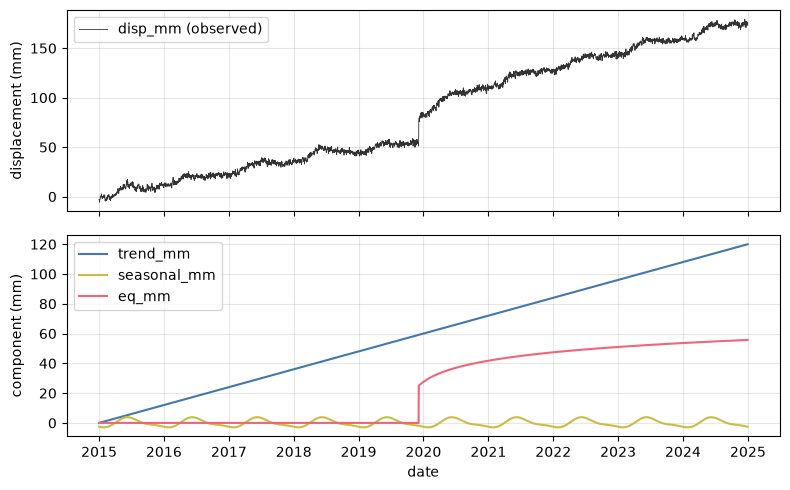

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

axes[0].plot(gnss["date"], gnss["disp_mm"], color="#333333", lw=0.6,
             label="disp_mm (observed)")
axes[0].set_ylabel("displacement (mm)")
axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.3)

axes[1].plot(gnss["date"], gnss["trend_mm"], color="#4477AA", label="trend_mm")
axes[1].plot(gnss["date"], gnss["seasonal_mm"], color="#CCBB44", label="seasonal_mm")
axes[1].plot(gnss["date"], gnss["eq_mm"], color="#EE6677", label="eq_mm")
axes[1].set_ylabel("component (mm)")
axes[1].set_xlabel("date")
axes[1].legend(loc="upper left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Le saut cosismique et la récupération postsismique incurvée reposent sur une tendance régulière d'environ 12 mm/an et un cycle saisonnier de quelques millimètres. La tâche de prévision : étant donné les 90 derniers jours de déplacement, prédire les 30 jours suivants.

## 3. Paires supervisées et découpage temporel

Quatre règles de prétraitement pour la prévision de séquences :

1. **Standardisez** la série (soustraire la moyenne, diviser par l'écart-type) pour que le réseau s'entraîne sur des valeurs proches de zéro. Calculez les statistiques sur la seule portion d'entraînement, puis appliquez-les partout.
2. **Faites glisser une fenêtre** sur la série pour construire des paires (entrée, cible) : 90 jours de contexte en entrée, les 30 jours suivants en cible.
3. **Découpez dans le temps, pas au hasard.** Les 8 premières années deviennent les données d'entraînement, les 2 dernières la validation. Aucune fenêtre ne traverse la frontière du découpage, et aucune donnée n'est mélangée à travers elle. Mélanger les fenêtres *au sein* de l'ensemble d'entraînement pendant l'entraînement ne pose pas de problème.
4. **Ancrez chaque fenêtre.** Soustrayez la dernière valeur du contexte à la fois du contexte et de la cible, pour que le modèle prévoie un *changement* relatif à l'observation la plus récente. Cette série monte pendant 10 ans : les fenêtres de validation se situent donc à des niveaux absolus que l'ensemble d'entraînement n'a jamais contenus ; sans ancrage, chaque modèle devrait extrapoler hors de sa plage d'entraînement et les modèles saturants (tanh, sigmoïde) échoueraient lourdement. Essayez plus tard de retirer l'ancrage et regardez les erreurs de validation grossir.

Un découpage aléatoire ferait fuir de l'information : une fenêtre de « validation » pourrait recouvrir presque entièrement deux fenêtres d'entraînement qui l'encadrent, et le score de validation ne dirait rien sur la prévision d'un temps véritablement inédit.

In [4]:
WINDOW, HORIZON = 90, 30

series = gnss["disp_mm"].to_numpy(dtype=np.float32)
n_days = len(series)
split = int(0.8 * n_days)  # first 8 years train, last 2 years validation

mu = float(series[:split].mean())
sigma = float(series[:split].std())
z = (series - mu) / sigma
print(f"training-portion mean {mu:.1f} mm, std {sigma:.1f} mm")


def make_windows(z, start, stop, window=WINDOW, horizon=HORIZON):
    """Build anchored (window, horizon) pairs from z[start:stop]."""
    X, Y = [], []
    for i in range(start, stop - window - horizon + 1):
        X.append(z[i : i + window])
        Y.append(z[i + window : i + window + horizon])
    X = np.stack(X)[..., np.newaxis]      # (n_pairs, window, 1)
    Y = np.stack(Y)                       # (n_pairs, horizon)
    anchor = X[:, -1:, 0].copy()          # last context value, (n_pairs, 1)
    X = X - anchor[:, :, np.newaxis]      # context relative to its last day
    Y = Y - anchor                        # target relative to the same day
    return (torch.from_numpy(X), torch.from_numpy(Y),
            torch.from_numpy(anchor))


X_train, Y_train, anc_train = make_windows(z, 0, split)
X_val, Y_val, anc_val = make_windows(z, split, n_days)
print("train:", tuple(X_train.shape), "->", tuple(Y_train.shape))
print("val:  ", tuple(X_val.shape), "->", tuple(Y_val.shape))

training-portion mean 64.4 mm, std 46.6 mm
train: (2802, 90, 1) -> (2802, 30)
val:   (612, 90, 1) -> (612, 30)


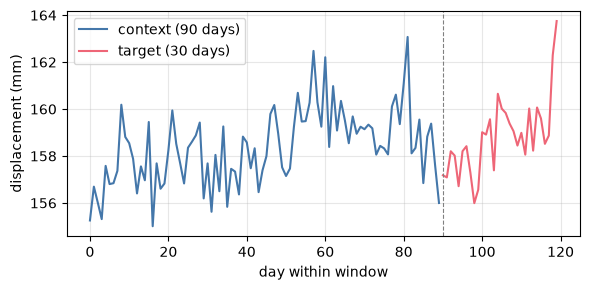

In [5]:
i = 300  # one validation pair, shown in original units
a = anc_val[i].item()
ctx_mm = (X_val[i, :, 0].numpy() + a) * sigma + mu
tgt_mm = (Y_val[i].numpy() + a) * sigma + mu

plt.figure(figsize=(6, 3))
plt.plot(np.arange(WINDOW), ctx_mm, color="#4477AA", label="context (90 days)")
plt.plot(np.arange(WINDOW, WINDOW + HORIZON), tgt_mm, color="#EE6677",
         label="target (30 days)")
plt.axvline(WINDOW, color="gray", lw=0.8, ls="--")
plt.xlabel("day within window")
plt.ylabel("displacement (mm)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Une seule boucle d'entraînement, une seule métrique

Chaque modèle ci-dessous transforme un contexte (90, 1) en 30 valeurs de prévision. Pour garder la comparaison équitable, tous partagent les mêmes fenêtres, la même perte (l'erreur quadratique moyenne, MSE, sur valeurs standardisées), les mêmes réglages d'optimiseur et la même métrique de validation : l'**erreur absolue moyenne (MAE) sur l'horizon de 30 jours, reconvertie en millimètres**.

L'entraînement dure 20 époques, ce qui suffit pour des modèles aussi petits. Augmentez le nombre d'époques sur votre propre machine si vous voulez une convergence plus serrée.

In [6]:
results = {}


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def val_mae_mm(model):
    """Mean absolute error on the validation windows, in millimeters."""
    model.eval()
    with torch.no_grad():
        pred = model(X_val.to(device)).cpu()
    return (pred - Y_val).abs().mean().item() * sigma


def train_model(model, name, n_epochs=20, lr=1e-3, batch_size=64):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    n = X_train.shape[0]
    history = {"train": [], "val": []}
    t0 = time.time()
    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(n)  # shuffle within the training set only
        running = 0.0
        for j in range(0, n, batch_size):
            idx = perm[j : j + batch_size]
            xb, yb = X_train[idx].to(device), Y_train[idx].to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            running += loss.item() * len(idx)
        history["train"].append(running / n)
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val.to(device)), Y_val.to(device)).item()
        history["val"].append(val_loss)
        if (epoch + 1) % 5 == 0:
            print(f"[{name}] epoch {epoch + 1:2d}  "
                  f"train MSE {history['train'][-1]:.4f}  val MSE {val_loss:.4f}")
    elapsed = time.time() - t0
    mae = val_mae_mm(model)
    results[name] = {"model": model, "history": history,
                     "n_params": count_params(model),
                     "train_time_s": elapsed, "val_mae_mm": mae}
    print(f"[{name}] {count_params(model):,} parameters, "
          f"trained in {elapsed:.1f} s, val MAE {mae:.2f} mm")

## 5. RNN simple

`torch.nn.RNN` implémente la cellule récurrente simple. À chaque pas de temps, elle met à jour l'état caché selon $h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$ : la nouvelle entrée mélangée à l'état caché précédent. Nous lisons l'état caché après le dernier des 90 pas et le projetons vers 30 valeurs de prévision par une couche linéaire.

In [7]:
class VanillaRNN(torch.nn.Module):
    def __init__(self, hidden_size=32, horizon=HORIZON):
        super().__init__()
        self.rnn = torch.nn.RNN(1, hidden_size, batch_first=True)
        self.head = torch.nn.Linear(hidden_size, horizon)

    def forward(self, x):                # x: (batch, window, 1)
        out, _ = self.rnn(x)             # out: (batch, window, hidden)
        return self.head(out[:, -1, :])  # last hidden state -> 30 values


train_model(VanillaRNN(), "RNN")

[RNN] epoch  5  train MSE 0.0044  val MSE 0.0027


[RNN] epoch 10  train MSE 0.0042  val MSE 0.0025


[RNN] epoch 15  train MSE 0.0042  val MSE 0.0026


[RNN] epoch 20  train MSE 0.0042  val MSE 0.0025
[RNN] 2,110 parameters, trained in 4.5 s, val MAE 1.83 mm


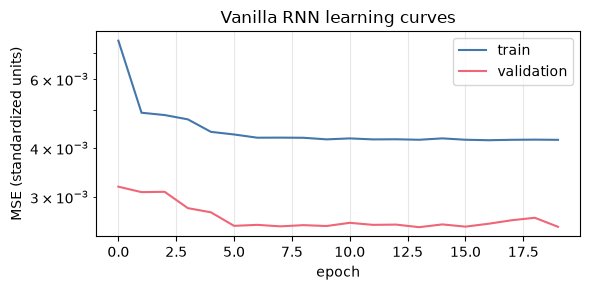

In [8]:
hist = results["RNN"]["history"]
plt.figure(figsize=(6, 3))
plt.plot(hist["train"], color="#4477AA", label="train")
plt.plot(hist["val"], color="#EE6677", label="validation")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE (standardized units)")
plt.title("Vanilla RNN learning curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Pourquoi les RNN simples oublient : gradients évanescents et gradients explosifs

Entraîner un réseau récurrent utilise la rétropropagation dans le temps (BPTT) : dérouler le réseau sur les 90 pas de temps, puis pousser le gradient de la perte à rebours à travers chaque pas. Le gradient qui atteint le pas 1 est un produit d'environ 90 matrices jacobiennes, une par pas. Multipliez 90 nombres légèrement inférieurs à un et le produit est presque nul ; multipliez 90 nombres légèrement supérieurs à un et il explose. Les produits de matrices se comportent de la même façon : la multiplication répétée rétrécit ou grossit exponentiellement avec la longueur de la séquence.

Quand le produit rétrécit — le cas courant avec des cellules tanh — les premiers pas de temps ne reçoivent presque aucun gradient. Le réseau ne peut pas apprendre que quelque chose survenu 80 jours en arrière compte pour la prévision, parce que le signal d'entraînement n'atteint jamais un passé aussi lointain. C'est le problème du **gradient évanescent**, et c'est la raison pour laquelle la mémoire récurrente simple plafonne autour de quelques dizaines de pas. Quand le produit grossit au contraire, l'entraînement devient instable ; l'écrêtage de gradient (*gradient clipping*) garde ce cas sous contrôle, mais il n'existe pas de remède aussi simple à l'évanescence.

Deux familles de remèdes ont changé le domaine. Le LSTM (1997) ajoute une cellule mémoire à portes dont l'état est mis à jour par addition plutôt que par multiplication répétée, offrant aux gradients un chemin qui ne rétrécit pas. L'attention, introduite par Bahdanau et al. (2014) comme complément aux modèles récurrents séquence-à-séquence, permet à chaque pas de temps de se connecter directement à tous les autres ; le *transformer* (Vaswani et al., 2017, « Attention is all you need ») a ensuite supprimé entièrement la récurrence, si bien qu'aucun gradient n'a à survivre à un produit de 90 pas. Nous construisons les deux dans la suite.

## 7. LSTM

La cellule LSTM (*Long Short-Term Memory* : une mémoire à court terme qui dure) transporte un état de cellule interne à côté de l'état caché et le contrôle par trois portes apprises. La **porte d'oubli** décide quelle part de l'état de cellule précédent conserver, la **porte d'entrée** décide quelle part de nouvelle information candidate y écrire, et la **porte de sortie** décide quelle part de l'état de cellule exposer comme état caché. Parce que l'état de cellule est mis à jour par addition, les gradients peuvent traverser de nombreux pas de temps sans s'évanouir. Le prix : environ quatre fois plus de paramètres qu'une cellule RNN simple de même largeur.

![LSTM](../img/lstm-2.svg)

Remplacer `nn.RNN` par `nn.LSTM` est un changement d'une ligne ; le reste du modèle et l'appel d'entraînement sont identiques.

In [9]:
class LSTMForecaster(torch.nn.Module):
    def __init__(self, hidden_size=32, horizon=HORIZON):
        super().__init__()
        self.lstm = torch.nn.LSTM(1, hidden_size, batch_first=True)
        self.head = torch.nn.Linear(hidden_size, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])


train_model(LSTMForecaster(), "LSTM")

[LSTM] epoch  5  train MSE 0.0047  val MSE 0.0028


[LSTM] epoch 10  train MSE 0.0042  val MSE 0.0025


[LSTM] epoch 15  train MSE 0.0042  val MSE 0.0025


[LSTM] epoch 20  train MSE 0.0042  val MSE 0.0026
[LSTM] 5,470 parameters, trained in 13.6 s, val MAE 1.86 mm


## 8. L'auto-attention à partir de zéro

L'attention emprunte une autre voie : abandonner la récurrence et laisser chaque pas de temps regarder directement tous les autres. Chaque position de la fenêtre émet une **requête** (*query*, « qu'est-ce que je cherche ? »), une **clé** (*key*, « qu'est-ce que je contiens ? ») et une **valeur** (*value*, « qu'est-ce que je transmets ? »). La sortie à chaque position est une moyenne pondérée de toutes les valeurs, avec des poids fixés par l'adéquation entre la requête de cette position et chaque clé. Une tête d'attention tient en une quinzaine de lignes de PyTorch.

In [10]:
class TinyAttention(torch.nn.Module):
    def __init__(self, d_model=32, horizon=HORIZON):
        super().__init__()
        self.embed = torch.nn.Linear(1, d_model)  # lift each scalar to a vector
        self.Wq = torch.nn.Linear(d_model, d_model, bias=False)
        self.Wk = torch.nn.Linear(d_model, d_model, bias=False)
        self.Wv = torch.nn.Linear(d_model, d_model, bias=False)
        self.head = torch.nn.Linear(d_model, horizon)
        self.scale = d_model ** 0.5

    def forward(self, x):                              # x: (batch, window, 1)
        h = self.embed(x)                              # (batch, window, d_model)
        Q, K, V = self.Wq(h), self.Wk(h), self.Wv(h)   # three views of h
        scores = Q @ K.transpose(1, 2) / self.scale    # (batch, window, window)
        weights = torch.softmax(scores, dim=-1)        # rows sum to one
        context = weights @ V                          # weighted sum of values
        return self.head(context.mean(dim=1))          # mean-pool, then forecast

Ligne à ligne :

- `self.embed` élève chaque déplacement scalaire en un vecteur de dimension `d_model` ; l'attention opère sur des vecteurs, pas sur des scalaires.
- `Wq`, `Wk`, `Wv` sont trois applications linéaires qui produisent les requêtes `Q`, les clés `K` et les valeurs `V`, chacune de forme (batch, 90, `d_model`). Ce sont trois « vues » apprises de la même séquence après plongement (*embedding*).
- `Q @ K.transpose(1, 2)` calcule tous les produits scalaires requête-clé d'un coup : une matrice de scores 90 par 90 par échantillon. L'élément $(i, j)$ mesure la pertinence du jour $j$ pour le jour $i$.
- Diviser par $\sqrt{d_{model}}$ garde les scores près de l'échelle unité, pour que le softmax ne sature pas.
- `softmax(scores, dim=-1)` transforme chaque ligne de scores en poids positifs dont la somme vaut un.
- `weights @ V` forme la moyenne pondérée : la sortie de chaque jour mélange l'information des 90 jours, proches ou lointains, au même coût. Nulle part un produit de 90 jacobiennes.
- Nous moyennons sur les 90 positions (*mean pooling*) et appliquons une tête linéaire pour produire les 30 valeurs de prévision.

Notez ce qui manque : rien dans ces lignes ne connaît l'*ordre* des pas de temps. Mélangez les 90 jours d'une fenêtre et la sortie moyennée est identique. Le *transformer* corrige cela avec les encodages positionnels.

In [11]:
train_model(TinyAttention(), "Attention")

[Attention] epoch  5  train MSE 0.0047  val MSE 0.0028


[Attention] epoch 10  train MSE 0.0045  val MSE 0.0026


[Attention] epoch 15  train MSE 0.0045  val MSE 0.0026


[Attention] epoch 20  train MSE 0.0045  val MSE 0.0026
[Attention] 4,126 parameters, trained in 8.5 s, val MAE 1.87 mm


## 9. Encodeur *transformer*

Une couche d'encodeur *transformer*, c'est de l'auto-attention plus un petit réseau à propagation avant (*feed-forward*), avec des connexions résiduelles et une normalisation de couche autour de chacun, et généralement plusieurs têtes d'attention en parallèle. PyTorch fournit le bloc entier sous le nom `torch.nn.TransformerEncoderLayer` ; nous en empilons deux avec `torch.nn.TransformerEncoder`.

Parce que l'attention est aveugle à l'ordre, nous ajoutons d'abord un **encodage positionnel** aux entrées après plongement : un motif fixe de sinus et de cosinus à différentes fréquences, un vecteur par position. Après cette addition, le jour 3 et le jour 73 d'une fenêtre paraissent différents au modèle même quand leurs valeurs de déplacement sont égales.

In [12]:
class PositionalEncoding(torch.nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pos = torch.arange(max_len).unsqueeze(1).float()
        freq = torch.exp(torch.arange(0, d_model, 2).float()
                         * (-np.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(pos * freq)
        pe[:, 1::2] = torch.cos(pos * freq)
        self.register_buffer("pe", pe)

    def forward(self, x):                 # x: (batch, seq, d_model)
        return x + self.pe[: x.shape[1]]


class TinyTransformer(torch.nn.Module):
    def __init__(self, d_model=32, nhead=4, num_layers=2, horizon=HORIZON):
        super().__init__()
        self.embed = torch.nn.Linear(1, d_model)
        self.pos = PositionalEncoding(d_model)
        layer = torch.nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=64,
            dropout=0.0, batch_first=True)
        self.encoder = torch.nn.TransformerEncoder(
            layer, num_layers=num_layers, enable_nested_tensor=False)
        self.head = torch.nn.Linear(d_model, horizon)

    def forward(self, x):
        h = self.encoder(self.pos(self.embed(x)))
        return self.head(h.mean(dim=1))


train_model(TinyTransformer(), "Transformer")

[Transformer] epoch  5  train MSE 0.0049  val MSE 0.0031


[Transformer] epoch 10  train MSE 0.0049  val MSE 0.0031


[Transformer] epoch 15  train MSE 0.0046  val MSE 0.0027


[Transformer] epoch 20  train MSE 0.0042  val MSE 0.0025
[Transformer] 18,142 parameters, trained in 23.8 s, val MAE 1.84 mm


## 10. Comparaison

Les quatre modèles ont été entraînés sur les mêmes fenêtres et notés avec la même métrique : les chiffres ci-dessous sont donc directement comparables. Le tableau porte aussi deux lignes qui ne coûtent rien à entraîner :

- **Persistance** : chaque jour de la prévision égale le dernier jour du contexte. Dans nos coordonnées ancrées, cette prévision vaut exactement zéro, si bien que sa MAE tient en une ligne de code.
- **Naïf saisonnier** : chaque jour prévu égale la valeur observée 365 jours plus tôt — le bon modèle de référence pour une série purement saisonnière.

Un modèle de prévision appris qui ne bat pas la persistance n'a rien appris ; c'est la règle de lecture de chaque ligne d'architecture ci-dessous.

In [13]:
# Baselines that require no training
# persistence: in anchored coordinates the forecast is identically zero
mae_persistence = Y_val.abs().mean().item() * sigma

# seasonal naive: each forecast day equals the value 365 days earlier
starts = np.arange(split, n_days - WINDOW - HORIZON + 1)  # anchor day of each validation pair
seas_pred = np.stack([z[i + WINDOW - 365 : i + WINDOW + HORIZON - 365] for i in starts])
true_z = Y_val.numpy() + anc_val.numpy()                  # targets back in absolute z units
mae_seasonal = float(np.abs(seas_pred - true_z).mean() * sigma)

baseline_rows = [
    {"model": "persistence (last value)", "parameters": 0, "train time (s)": 0.0,
     "val MAE, 30-day horizon (mm)": round(mae_persistence, 2)},
    {"model": "seasonal naive (365 d earlier)", "parameters": 0, "train time (s)": 0.0,
     "val MAE, 30-day horizon (mm)": round(mae_seasonal, 2)},
]
comparison = pd.DataFrame(
    baseline_rows +
    [{"model": name,
      "parameters": r["n_params"],
      "train time (s)": round(r["train_time_s"], 1),
      "val MAE, 30-day horizon (mm)": round(r["val_mae_mm"], 2)}
     for name, r in results.items()]
).set_index("model")
comparison

,parameters,train time (s),"val MAE, 30-day horizon (mm)"
model,,,
persistence (last value),0,0.0,2.10
seasonal naive (365 d earlier),0,0.0,15.53
RNN,2110,4.5,1.83
LSTM,5470,13.6,1.86
Attention,4126,8.5,1.87
Transformer,18142,23.8,1.84


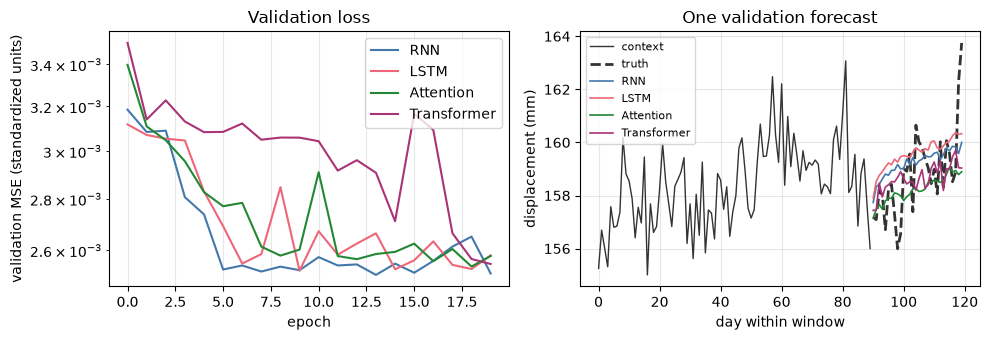

In [14]:
model_colors = {"RNN": "#4477AA", "LSTM": "#EE6677",
                "Attention": "#228833", "Transformer": "#AA3377"}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for name, r in results.items():
    axes[0].plot(r["history"]["val"], color=model_colors[name], label=name)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("validation MSE (standardized units)")
axes[0].set_title("Validation loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

i = 300  # same validation window as before
a = anc_val[i].item()
t_ctx = np.arange(WINDOW)
t_fut = np.arange(WINDOW, WINDOW + HORIZON)
axes[1].plot(t_ctx, (X_val[i, :, 0].numpy() + a) * sigma + mu,
             color="#333333", lw=1, label="context")
axes[1].plot(t_fut, (Y_val[i].numpy() + a) * sigma + mu,
             color="#333333", lw=2, ls="--", label="truth")
for name, r in results.items():
    r["model"].eval()
    with torch.no_grad():
        pred = r["model"](X_val[i : i + 1].to(device)).cpu().numpy()[0]
    axes[1].plot(t_fut, (pred + a) * sigma + mu, color=model_colors[name],
                 lw=1.2, label=name)
axes[1].set_xlabel("day within window")
axes[1].set_ylabel("displacement (mm)")
axes[1].set_title("One validation forecast")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Commencez par les lignes de référence. La persistance obtient 2,10 mm et les quatre modèles appris se placent entre 1,83 et 1,87 mm : une amélioration d'environ 13 %, réelle mais modeste, ce qui est la bonne conclusion à retenir pour une série à ce point dominée par une tendance lisse et la saisonnalité. Le naïf saisonnier échoue à 15,5 mm — la valeur d'il y a 365 jours est systématiquement environ 12 mm trop basse sur une tendance tectonique de 12 mm/an — rappel qu'un modèle de référence n'informe que s'il correspond à la structure qu'elle vise. Les quatre scores appris se tiennent de près, et c'est attendu. Cette série synthétique est dominée par une tendance et un cycle saisonnier que toute architecture peut extraire d'un contexte de 90 jours, et 20 époques sur quelques milliers de fenêtres laissent du bruit dans le classement ; relancez avec une autre graine et l'ordre peut se réarranger. **Le classement n'est pas la leçon. La mécanique l'est** : comment chaque architecture déplace l'information à travers le temps, et ce que cela coûte en paramètres et en comportement des gradients.

### Exercice

Doublez l'horizon de prévision à 60 jours (posez `HORIZON = 60`, reconstruisez les fenêtres, réentraînez les quatre modèles). Comment les MAE de validation changent-elles, et pourquoi ?

```{admonition} Solution
:class: dropdown
Les quatre MAE augmentent, parce que l'incertitude s'accumule avec l'échéance : le jour 60 dépend du bruit, de la phase saisonnière et de tout comportement transitoire que le contexte de 90 jours contraint de moins en moins. L'erreur n'est pas non plus uniforme sur l'horizon ; si vous calculez la MAE par jour d'échéance, les premiers jours de la prévision sont bien meilleurs que les derniers. Le classement relatif des quatre modèles reste généralement dans le bruit sur cette série synthétique.
```

## 11. Résumé

- Une tâche de prévision se définit par sa **fenêtre de contexte** et son **horizon de prévision** ; les paires supervisées viennent du glissement de cette fenêtre sur la série, avec un découpage temporel entraînement/validation pour qu'aucune information ne fuie à travers la frontière.
- Un **RNN simple** transporte un état caché à travers le temps mais ne peut pas apprendre de structure à longue portée, parce que la BPTT multiplie environ une jacobienne par pas de temps et que le produit s'évanouit ou explose.
- Le **LSTM** fait circuler l'information par un état de cellule mis à jour additivement, contrôlé par les portes d'oubli, d'entrée et de sortie, si bien que les gradients survivent aux longues séquences.
- L'**auto-attention** connecte chaque pas de temps à tous les autres en une seule opération : requêtes, clés, valeurs, produits scalaires mis à l'échelle, softmax, somme pondérée. Un **encodeur *transformer*** enveloppe cela de connexions résiduelles, de normalisation de couche et de blocs à propagation avant, plus des encodages positionnels pour restaurer l'information d'ordre.

L'attention est la brique de base des systèmes de prévision actuels, des modèles météorologiques par apprentissage automatique aux modèles de prévision de séries temporelles pré-entraînés. Le carnet 4.10 mène une comparaison de prévision de ces architectures sur des données géoscientifiques réelles.